# A/B Testing: Expected Revenue

<img style="float: right;" width=40% src="./ab-testing.jpg">

There are many rules of thumb in designing web interfaces such as never use comic sans, or the `<blink>` tag. However, it is not always so easy to decide between several designs.

Another possibly interesting factor－in choosing a web design－is finding out which design results in larger revenue.

Consider a website where users may perform 4 possible actions. Lets denote these actions $a_{79}$, $a_{49}$, $a_{25}$ and $a_0$. The subindex of the action corresponds to the amount of money online service earns if the user performs the action. For instance, if the user performs action $a_{79}$, the online service earns 79 DKK. The action $a_0$ corresponds to the user doing nothing of value (for the online service).

The company has developed two designs for their website; we denote them as A and B. In order to determine which design is more profitable they have collected data from several users. To collect this data, the company randomly has shown design A or B to the users, and recorded which action they performed. Users can only perform one action when visiting the website; i.e., actions are mutually exclusive.

**Exercise 1.** Use PyMC to quantify the expected revenue of two different web designs. The expected revenue is defined as follows:
$$ \mathit{expected\_revenue} = 79 \cdot p_{79} + 49 \cdot p_{49} + 25 \cdot p_{25} + 0 \cdot p_{0}$$
where $p_{i}$ denotes the probability of the user performing action $a_i$.

In [1]:
import pymc as pm
import arviz as az
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# data

# design A
N_a    = 1000
N_a_79 = 10 
N_a_49 = 46
N_a_25 = 80
N_a_0  = N_a - (N_a_79+N_a_49+N_a_25)

# design B
N_b    = 2000
N_b_79 = 45
N_b_49 = 84
N_b_25 = 200
N_b_0  = N_b - (N_b_79+N_b_49+N_b_25)


In [11]:
a_data=[N_a_79, N_a_49, N_a_25, N_a_0]
N= N_a

with pm.Model() as Model_A:
    # prior
    θ = pm.Dirichlet('θ', a=np.array([1,1,1,1]))
    
    # likelihood
    pm.Multinomial('obs', n=N, p=θ, observed=a_data)
    
    # distributions of (possible) interest
    # pm.Deterministic('cumulative_probability_3',θ[0]+θ[1]+θ[2])

# plotting the model for presentation
# pm.model_to_graphviz(Model_A)

expected_revenue = 79 * N_a_79 + 49 * N_a_79 + 25 * N_a_79 + 0 * N_a_79
# predicted_revenue = 79 * θ[0] + 49 * θ[1] + 25 * θ[2] + 0 * θ[3]

print(f"Expected revenue: {expected_revenue}")
# print(f"Predicted revenue: {predicted_revenue}")

Expected revenue: 1530


In [12]:
with Model_A:
    # sample from the posterior
    trace_a = pm.sample(2000, tune=1000, return_inferencedata=False)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [θ]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 43 seconds.


In [14]:
trace_a

<MultiTrace: 4 chains, 2000 iterations, 2 variables>

Predicted revenue: 5.181864624677686
Sum predicted revenue: 41454.91699742148


Text(0.5, 0, 'Predicted Revenue')

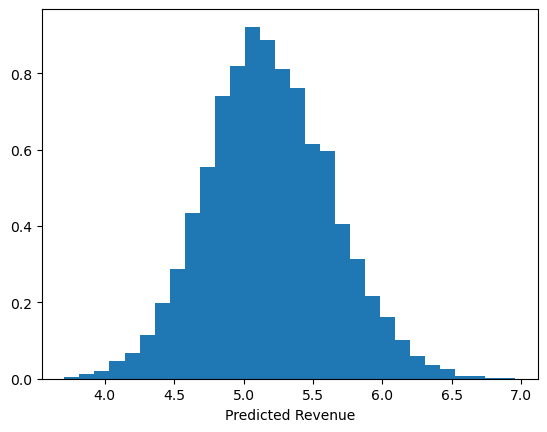

In [15]:
predicted_revenue = 79 * trace_a['θ'][:,0] + 49 * trace_a['θ'][:,1] + 25 * trace_a['θ'][:,2] + 0 * trace_a['θ'][:,3]

print(f"Predicted revenue: {predicted_revenue.mean()}")
sum_predicted_revenue = np.sum(predicted_revenue)
print(f"Sum predicted revenue: {sum_predicted_revenue}")
# plot posterior predictive distribution
plt.hist(predicted_revenue, bins=30, density=True)
plt.xlabel('Predicted Revenue')

In [17]:
with pm.Model() as Model_B:
    # prior
    θ = pm.Dirichlet('θ', a=np.array([1,1,1,1]))
    
    # likelihood
    pm.Multinomial('obs', n=N_b, p=θ, observed=[N_b_79, N_b_49, N_b_25, N_b_0])
    
    # distributions of (possible) interest
    # pm.Deterministic('cumulative_probability_3',θ[0]+θ[1]+θ[2])
    
expected_revenue_b = 79 * N_b_79 + 49 * N_b_49 + 25 * N_b_25 + 0 * N_b_0

print(f"Expected revenue: {expected_revenue_b}")

Expected revenue: 12671


In [18]:
with Model_B:
    # sample from the posterior
    trace_b = pm.sample(2000, tune=1000, return_inferencedata=False)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [θ]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 45 seconds.


In [19]:
predicted_revenue_b = 79 * trace_b['θ'][:,0] + 49 * trace_b['θ'][:,1] + 25 * trace_b['θ'][:,2] + 0 * trace_b['θ'][:,3]
print(f"Predicted revenue: {predicted_revenue_b.mean()}")
sum_predicted_revenue_b = np.sum(predicted_revenue_b)
print(f"Sum predicted revenue: {sum_predicted_revenue_b}")

Predicted revenue: 6.395790604064925
Sum predicted revenue: 51166.3248325194
